# Functional Connectivity Matrix for One Subject

## Goal

This notebook builds the first functional connectivity matrix from resting-state fMRI data.

The pipeline:

1. Download one preprocessed resting-state fMRI file.
2. Load a brain atlas.
3. Extract regional BOLD time series.
4. Compute a ROI-to-ROI correlation matrix.
5. Save the matrix for future group-level analysis.

This notebook uses one subject first to validate the pipeline before scaling to multiple diagnostic groups.

In [1]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nilearn import datasets
from nilearn.maskers import NiftiLabelsMasker
from nilearn.connectome import ConnectivityMeasure
from nilearn import plotting

In [2]:
PROJECT_ROOT = Path("..").resolve()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('C:/Users/vi/psychiatric-brain-connectivity-analysis')

In [3]:
subject_id = "sub-10159"

filename = f"{subject_id}_task-rest_bold_space-MNI152NLin2009cAsym_preproc.nii.gz"

subject_func_dir = RAW_DIR / subject_id / "func"
subject_func_dir.mkdir(parents=True, exist_ok=True)

func_path = subject_func_dir / filename

candidate_urls = [
    f"https://s3.amazonaws.com/openneuro/ds000030/ds000030_R1.0.4/uncompressed/derivatives/fmriprep/{subject_id}/func/{filename}",
    f"https://s3.amazonaws.com/openneuro/ds000030/ds000030_R1.0.5/uncompressed/derivatives/fmriprep/{subject_id}/func/{filename}",
]

if not func_path.exists():
    last_error = None
    
    for url in candidate_urls:
        try:
            print(f"Trying download from:\n{url}")
            urlretrieve(url, func_path)
            print(f"Downloaded to: {func_path}")
            break
        except Exception as error:
            last_error = error
            print(f"Failed: {error}")
    
    if not func_path.exists():
        raise RuntimeError(f"Could not download file. Last error: {last_error}")
else:
    print(f"File already exists: {func_path}")

Trying download from:
https://s3.amazonaws.com/openneuro/ds000030/ds000030_R1.0.4/uncompressed/derivatives/fmriprep/sub-10159/func/sub-10159_task-rest_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
Failed: <urlopen error [Errno 11001] getaddrinfo failed>
Trying download from:
https://s3.amazonaws.com/openneuro/ds000030/ds000030_R1.0.5/uncompressed/derivatives/fmriprep/sub-10159/func/sub-10159_task-rest_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
Downloaded to: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\raw\sub-10159\func\sub-10159_task-rest_bold_space-MNI152NLin2009cAsym_preproc.nii.gz


In [4]:
print(func_path)
print(f"File size: {func_path.stat().st_size / 1024 / 1024:.2f} MB")

C:\Users\vi\psychiatric-brain-connectivity-analysis\data\raw\sub-10159\func\sub-10159_task-rest_bold_space-MNI152NLin2009cAsym_preproc.nii.gz
File size: 95.39 MB


In [5]:
atlas = datasets.fetch_atlas_harvard_oxford(
    atlas_name="cort-maxprob-thr25-2mm"
)

atlas_filename = atlas.maps
atlas_labels = atlas.labels

print(f"Atlas file: {atlas_filename}")
print(f"Number of labels including background: {len(atlas_labels)}")
print(atlas_labels[:10])

[fetch_atlas_harvard_oxford] Added README.md to C:\Users\vi\nilearn_data
[fetch_atlas_harvard_oxford] Dataset created in C:\Users\vi\nilearn_data\fsl
[fetch_atlas_harvard_oxford] Downloading data from https://www.nitrc.org/frs/download.php/9902/HarvardOxford.tgz ...
Downloaded 942080 of 25716861 bytes (3.7%%,   30.4s remaining)
Downloaded 3776512 of 25716861 bytes (14.7%%,   12.7s remaining)
Downloaded 6823936 of 25716861 bytes (26.5%%,    8.9s remaining)
Downloaded 10092544 of 25716861 bytes (39.2%%,    6.5s remaining)
Downloaded 13131776 of 25716861 bytes (51.1%%,    5.0s remaining)
Downloaded 16572416 of 25716861 bytes (64.4%%,    3.4s remaining)
Downloaded 19816448 of 25716861 bytes (77.1%%,    2.2s remaining)
Downloaded 22347776 of 25716861 bytes (86.9%%,    1.2s remaining)
Downloaded 24690688 of 25716861 bytes (96.0%%,    0.4s remaining)
[fetch_atlas_harvard_oxford]  ...done. (11 seconds, 0 min)

[fetch_atlas_harvard_oxford] Extracting data from C:\Users\vi\nilearn_data\fsl\35de8

In [6]:
masker = NiftiLabelsMasker(
    labels_img=atlas_filename,
    standardize="zscore_sample",
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0,
    verbose=1
)

time_series = masker.fit_transform(str(func_path))

print(f"Time series shape: {time_series.shape}")

[NiftiLabelsMasker.wrapped] Loading regions from <nibabel.nifti1.Nifti1Image object at 0x000001CDFFEB56D0>
[NiftiLabelsMasker.wrapped] Resampling regions
[NiftiLabelsMasker.wrapped] Finished fit
[NiftiLabelsMasker.wrapped] Loading data from 'C:\\Users\\vi\\psychiatric-brain-connectivity-analysis\\data\\raw\\sub-10159\\func\\sub-10159_task-rest_bold_space-MNI152NLin2009cAsym_preproc.nii.gz'
[NiftiLabelsMasker.wrapped] Extracting region signals
[NiftiLabelsMasker.wrapped] Cleaning extracted signals
Time series shape: (152, 48)


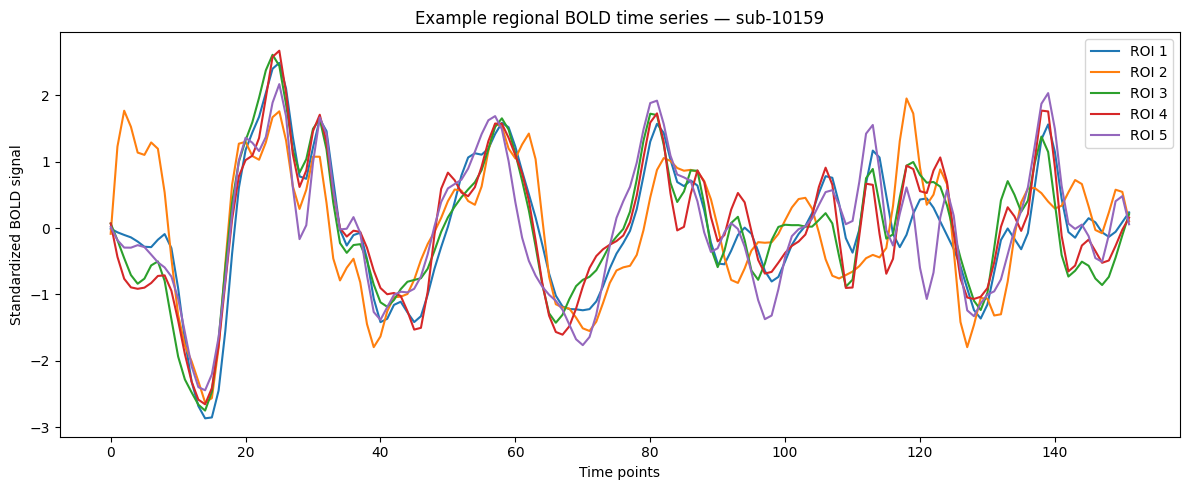

In [7]:
plt.figure(figsize=(12, 5))

for roi_idx in range(min(5, time_series.shape[1])):
    plt.plot(time_series[:, roi_idx], label=f"ROI {roi_idx + 1}")

plt.title(f"Example regional BOLD time series — {subject_id}")
plt.xlabel("Time points")
plt.ylabel("Standardized BOLD signal")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
correlation_measure = ConnectivityMeasure(
    kind="correlation",
    standardize="zscore_sample"
)

correlation_matrix = correlation_measure.fit_transform([time_series])[0]

np.fill_diagonal(correlation_matrix, 0)

print(f"Connectivity matrix shape: {correlation_matrix.shape}")

Connectivity matrix shape: (48, 48)


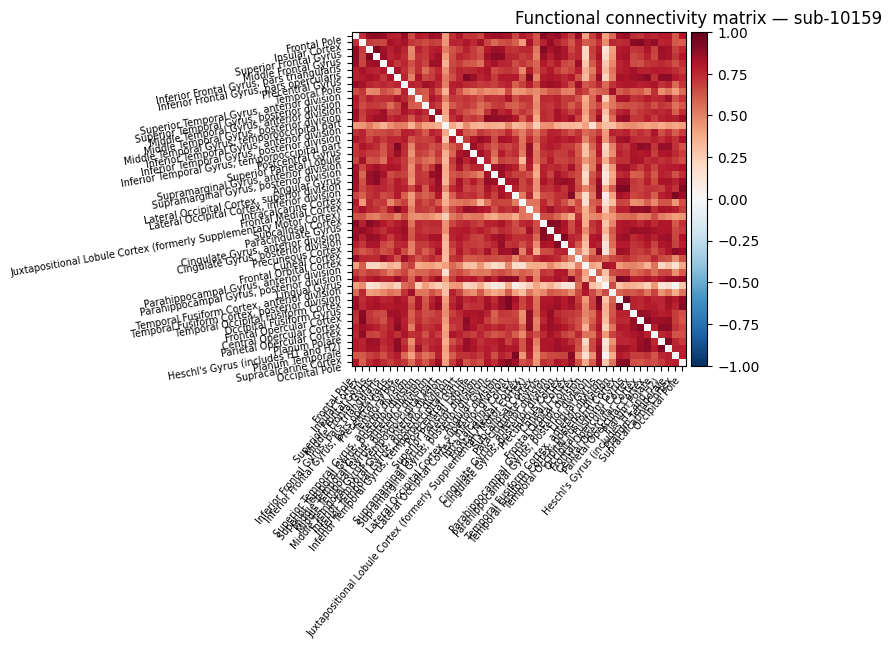

In [9]:
roi_labels = atlas_labels[1:]  # remove background label

plotting.plot_matrix(
    correlation_matrix,
    labels=roi_labels,
    figure=(10, 8),
    vmin=-1,
    vmax=1,
    reorder=False
)

plt.title(f"Functional connectivity matrix — {subject_id}")
plt.show()

In [10]:
connectivity_dir = PROCESSED_DIR / "connectivity"
connectivity_dir.mkdir(parents=True, exist_ok=True)

matrix_path = connectivity_dir / f"{subject_id}_connectivity_matrix.npy"
csv_path = connectivity_dir / f"{subject_id}_connectivity_matrix.csv"

np.save(matrix_path, correlation_matrix)

connectivity_df = pd.DataFrame(
    correlation_matrix,
    index=roi_labels,
    columns=roi_labels
)

connectivity_df.to_csv(csv_path)

print(f"Saved NumPy matrix to: {matrix_path}")
print(f"Saved CSV matrix to: {csv_path}")

Saved NumPy matrix to: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\processed\connectivity\sub-10159_connectivity_matrix.npy
Saved CSV matrix to: C:\Users\vi\psychiatric-brain-connectivity-analysis\data\processed\connectivity\sub-10159_connectivity_matrix.csv


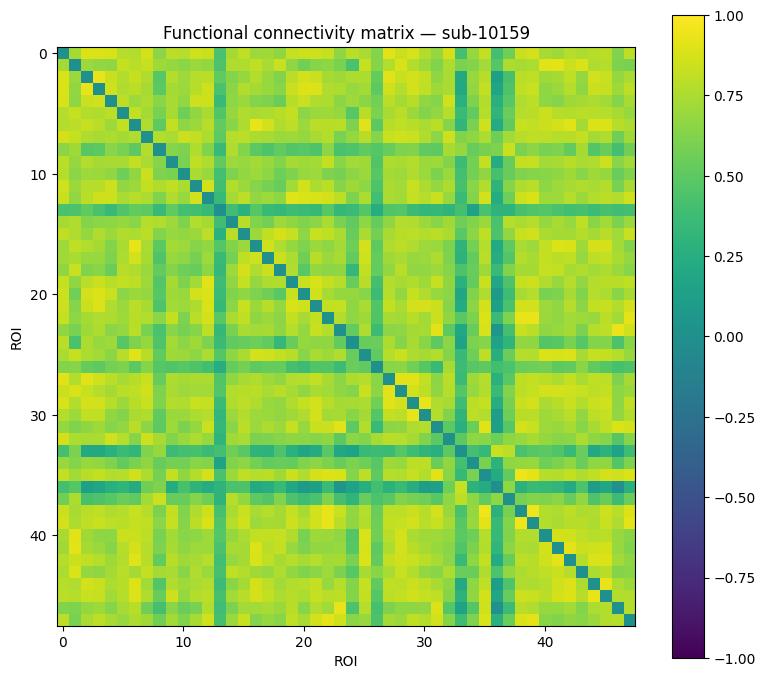

Saved figure to: C:\Users\vi\psychiatric-brain-connectivity-analysis\reports\figures\sub-10159_connectivity_matrix.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(correlation_matrix, vmin=-1, vmax=1)
fig.colorbar(im, ax=ax)

ax.set_title(f"Functional connectivity matrix — {subject_id}")
ax.set_xlabel("ROI")
ax.set_ylabel("ROI")

figure_path = FIGURES_DIR / f"{subject_id}_connectivity_matrix.png"

plt.tight_layout()
plt.savefig(figure_path, dpi=150)
plt.show()

print(f"Saved figure to: {figure_path}")

## Summary

This notebook successfully built a functional connectivity matrix for one resting-state fMRI subject.

Pipeline completed:

- downloaded one preprocessed resting-state fMRI file;
- loaded a cortical brain atlas;
- extracted regional BOLD time series;
- computed a ROI-to-ROI Pearson correlation matrix;
- saved the matrix and visualization.

Next step:

Scale this pipeline to multiple subjects across diagnostic groups and compare group-level connectivity patterns.